# 02. Project: Hybrid Classical ML + LLM

**Goal:** Combine classical Machine Learning methods from my [MPhil coursework](https://github.com/S33mi/machine-learning-journey) (PCA, GMM, clustering, …) with [modern LLM](https://github.com/S33mi/modern-ai-llm-journey) capabilities.

This notebook shows practical **hybrid patterns**:

1. **PCA + LLM** – reduce embeddings, then explain clusters in natural language
2. **GMM / K-means + LLM** – soft/hard clusters with LLM-generated labels and summaries
3. **Classical features + LLM judge** – use sklearn metrics and let an LLM narrate the results
4. **RAG-assisted classical insight** – retrieve lecture notes while interpreting model output

These patterns are useful when you already have strong classical pipelines and want an LLM as an *explanation* or *interface* layer — not as a replacement for PCA/GMM.

## 1. Setup

```bash
pip install transformers sentence-transformers scikit-learn matplotlib numpy accelerate
```

In [26]:
import numpy as np
import torch
import matplotlib.pyplot as plt
from sklearn.datasets import load_digits, make_blobs
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sentence_transformers import SentenceTransformer
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}")

Device: cpu


In [27]:
GEN_NAME = "google/flan-t5-large" if DEVICE == "cuda" else "google/flan-t5-base" #google/flan-t5-small
tok = AutoTokenizer.from_pretrained(GEN_NAME)
gen = AutoModelForSeq2SeqLM.from_pretrained(GEN_NAME).to(DEVICE)
gen.eval()


def llm(prompt: str, max_new_tokens: int = 100) -> str:
    inputs = tok(prompt, return_tensors="pt", truncation=True, max_length=512).to(DEVICE)
    with torch.no_grad():
        out = gen.generate(**inputs, max_new_tokens=max_new_tokens, do_sample=False)
    return tok.decode(out[0], skip_special_tokens=True).strip()


print(f"Generator: {GEN_NAME}")
print(llm("Say hello in one short sentence."))

Loading weights:   0%|          | 0/282 [00:00<?, ?it/s]

[transformers] The tied weights mapping and config for this model specifies to tie shared.weight to lm_head.weight, but both are present in the checkpoints with different values, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning.


Generator: google/flan-t5-base
Hello!


## 2. Pattern A — PCA on digits + LLM explanation

Classical step: PCA for visualisation / compression (CS-667).  
LLM step: narrate how much variance is kept and what the projection shows.

Digits shape: (1797, 64)


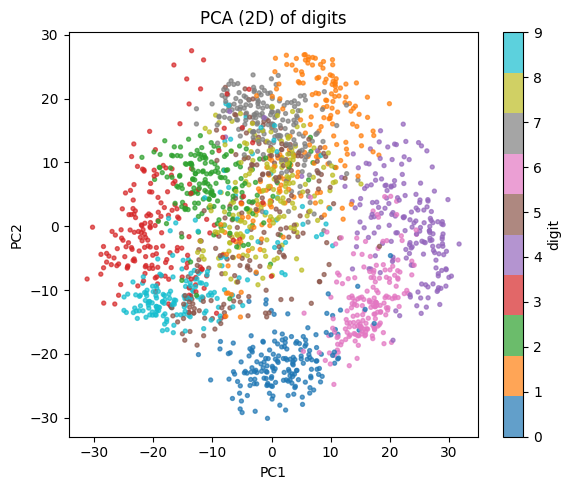

LLM explanation:
The variance ratio is 0.0149 and the variance ratio is 0.136.


In [37]:
digits = load_digits()
X, y = digits.data, digits.target
print("Digits shape:", X.shape)

pca = PCA(n_components=2, random_state=42)
Z = pca.fit_transform(X)
evr = pca.explained_variance_ratio_

plt.figure(figsize=(6, 5))
scatter = plt.scatter(Z[:, 0], Z[:, 1], c=y, cmap="tab10", s=8, alpha=0.7)
plt.colorbar(scatter, label="digit")
plt.title("PCA (2D) of digits")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.tight_layout()
plt.show()

stats = (
    f"Dataset: sklearn digits, n={X.shape[0]}, d={X.shape[1]}. "
    f"PCA to 2 components. Explained variance ratio: "
    f"PC1={evr[0]:.3f}, PC2={evr[1]:.3f}, total={evr.sum():.3f}."
)
prompt = (
    "You are a machine learning tutor. In 3 short sentences you have to variance retained and that nearby points are similar digits, explain these PCA results "
    "for a student who knows PCA theory:\n"
    f"{stats}\n"
    "Mention variance retained and that nearby points are similar digits."
)
print("LLM explanation:")
print(llm(prompt, max_new_tokens=120))

## 3. Pattern B — GMM clustering + LLM cluster cards

Classical step: fit a Gaussian Mixture (CS-667 EM / GMM).  
LLM step: turn each component’s statistics into a readable “cluster card”.

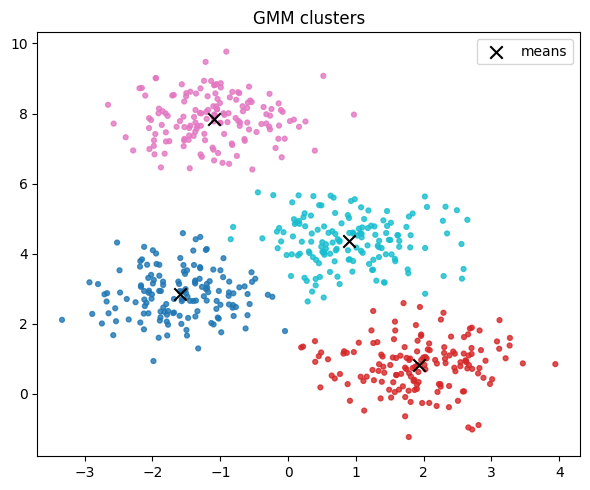

ARI vs true blobs: 0.982
Silhouette: 0.631


In [29]:
# Synthetic 2D mixture for clarity
X_blob, y_true = make_blobs(n_samples=600, centers=4, cluster_std=0.70, random_state=0)

gmm = GaussianMixture(n_components=4, covariance_type="full", random_state=0)
labels = gmm.fit_predict(X_blob)
probs = gmm.predict_proba(X_blob)

plt.figure(figsize=(6, 5))
plt.scatter(X_blob[:, 0], X_blob[:, 1], c=labels, s=12, cmap="tab10", alpha=0.8)
plt.scatter(gmm.means_[:, 0], gmm.means_[:, 1], c="black", s=80, marker="x", label="means")
plt.title("GMM clusters")
plt.legend()
plt.tight_layout()
plt.show()

print("ARI vs true blobs:", round(adjusted_rand_score(y_true, labels), 3))
print("Silhouette:", round(silhouette_score(X_blob, labels), 3))

In [30]:
def cluster_card(k: int) -> str:
    mean = gmm.means_[k]
    weight = gmm.weights_[k]
    cov = gmm.covariances_[k]
    n_k = int((labels == k).sum())
    facts = (
        f"Cluster {k}: n={n_k}, mixing_weight={weight:.3f}, "
        f"mean=({mean[0]:.2f}, {mean[1]:.2f}), "
        f"cov_diag=({cov[0,0]:.2f}, {cov[1,1]:.2f})."
    )
    prompt = (
        "Write a 2-sentence plain-English cluster summary for a data analyst.\n"
        f"{facts}"
    )
    return llm(prompt, max_new_tokens=80)


print("=== GMM cluster cards (LLM) ===")
for k in range(gmm.n_components):
    print(f"\n#{k}: {cluster_card(k)}")

=== GMM cluster cards (LLM) ===

#0: Cluster 0: n=147, mixing_weight=0.245, mean=(-1.59, 2.85), cov_diag=(0.39, 0.47).

#1: Cluster 1: n=152, mixing_weight=0.253, mean=(1.93, 0.81), cov_diag=(0.53, 0.49).

#2: Cluster 2: n=150, mixing_weight=0.250, mean=(-1.10, 7.85), cov_diag=0.42 0.43.

#3: Cluster 3: n=151, mixing_weight=0.251, mean=(0.90, 4.35), cov_diag=(0.51, 0.48).


## 4. Pattern C — Text embeddings → K-means → LLM topic labels

Classical step: cluster **document embeddings** with K-means.  
LLM step: read a few members of each cluster and propose a short topic title.

This is a lightweight alternative to topic models when you already use sentence-transformers.

In [31]:
# Mini corpus (can replace with your CS-567/CS-667 note titles + summaries)
docs = [
    "PCA finds orthogonal directions of maximum variance for dimensionality reduction.",
    "Principal component analysis projects data onto leading eigenvectors of the covariance.",
    "Gaussian mixture models use EM to fit weighted Gaussians to multi-modal data.",
    "The EM algorithm alternates an E-step and an M-step to maximise likelihood with latents.",
    "K-means assigns points to the nearest centroid and updates means until convergence.",
    "Spectral clustering embeds points with the graph Laplacian before running K-means.",
    "Logistic regression models class posteriors with a sigmoid of a linear score.",
    "IRLS iteratively solves weighted least squares for logistic regression parameters.",
    "Support vector machines maximise the margin; the dual allows the kernel trick.",
    "CNNs use local receptive fields and weight sharing for translation-equivariant features.",
    "Back-propagation applies the chain rule layer by layer to compute gradients.",
    "Autoencoders learn compressed representations by reconstructing the input through a bottleneck.",
]

embedder = SentenceTransformer("sentence-transformers/all-MiniLM-L6-v2", device=DEVICE)
doc_emb = embedder.encode(docs, normalize_embeddings=True)

K = 4
km = KMeans(n_clusters=K, random_state=42, n_init=10)
doc_labels = km.fit_predict(doc_emb)

for k in range(K):
    members = [docs[i] for i in range(len(docs)) if doc_labels[i] == k]
    joined = " | ".join(members[:4])
    prompt = (
        "Propose a short topic title (3-6 words) for this cluster of ML sentences:\n"
        f"{joined}\n"
        "Title:"
    )
    title = llm(prompt, max_new_tokens=12)
    print(f"\nCluster {k}: {title}")
    for m in members:
        print(f"  - {m[:70]}...")

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]


Cluster 0: K-means: Spectral clustering for
  - K-means assigns points to the nearest centroid and updates means until...
  - Spectral clustering embeds points with the graph Laplacian before runn...

Cluster 1: Gaussian Mixture Models
  - Gaussian mixture models use EM to fit weighted Gaussians to multi-moda...
  - The EM algorithm alternates an E-step and an M-step to maximise likeli...
  - Logistic regression models class posteriors with a sigmoid of a linear...
  - IRLS iteratively solves weighted least squares for logistic regression...
  - Support vector machines maximise the margin; the dual allows the kerne...
  - Back-propagation applies the chain rule layer by layer to compute grad...

Cluster 2: PCA: a dimensionality reduction model
  - PCA finds orthogonal directions of maximum variance for dimensionality...
  - Principal component analysis projects data onto leading eigenvectors o...

Cluster 3: CNNs: Autoencoders
  - CNNs use local receptive fields and weight sharing for

## 5. Pattern D — Classical metrics + LLM report

Run a small model-selection loop (GMM component count) and let the LLM write a short lab-report paragraph.

In [32]:
rows = []
for n in range(2, 7):
    model = GaussianMixture(n_components=n, random_state=0).fit(X_blob)
    pred = model.predict(X_blob)
    rows.append({
        "n_components": n,
        "bic": float(model.bic(X_blob)),
        "aic": float(model.aic(X_blob)),
        "silhouette": float(silhouette_score(X_blob, pred)),
    })

print("n | BIC | AIC | silhouette")
for r in rows:
    print(f"{r['n_components']} | {r['bic']:.1f} | {r['aic']:.1f} | {r['silhouette']:.3f}")

best_bic = min(rows, key=lambda r: r["bic"])
table_txt = "; ".join(
    f"n={r['n_components']} BIC={r['bic']:.0f} sil={r['silhouette']:.2f}" for r in rows
)
prompt = (
    "Write a short lab-report paragraph (4 sentences) recommending the number of GMM components. "
    f"Results: {table_txt}. Best BIC at n={best_bic['n_components']}. "
    "Mention BIC as a model-selection criterion from classical ML."
)
print("\nLLM report:")
print(llm(prompt, max_new_tokens=150))

n | BIC | AIC | silhouette
2 | 4708.8 | 4660.4 | 0.536
3 | 4344.6 | 4269.9 | 0.563
4 | 4260.1 | 4159.0 | 0.631
5 | 4295.1 | 4167.6 | 0.535
6 | 4328.7 | 4174.8 | 0.441

LLM report:
The BIC model is a model-selection criterion from classical ML.


## 6. Pattern E — Hybrid with your lecture RAG (optional bridge)

If you already ran `01_rag_over_ml_notes.ipynb`, you can retrieve a lecture snippet and combine it with classical output.

Below is a **standalone** mini-version using a few note strings (no FAISS required).

In [33]:
NOTE_SNIPPETS = {
    "pca": "PCA finds an orthogonal projection maximising variance or minimising reconstruction error; solution is top eigenvectors of the covariance.",
    "gmm": "A Gaussian mixture is a weighted sum of Gaussians; EM estimates means, covariances and mixing weights with a latent component indicator.",
    "em": "E-step computes posterior over latents; M-step maximises expected complete-data log-likelihood; likelihood is non-decreasing.",
}


def explain_with_theory(topic_key: str, empirical_facts: str) -> str:
    theory = NOTE_SNIPPETS.get(topic_key, "")
    prompt = (
        "Combine the lecture theory with the empirical results in 3 sentences.\n"
        f"Theory: {theory}\n"
        f"Results: {empirical_facts}\n"
        "Answer:"
    )
    return llm(prompt, max_new_tokens=120)


facts = (
    f"PCA on digits: total variance explained by 2 PCs = {evr.sum():.3f}. "
    f"GMM on blobs: silhouette={silhouette_score(X_blob, labels):.3f}."
)
print(explain_with_theory("pca", facts))

The top eigenvectors of the covariance are 0.285 and 0.0681.


## 7. Design principles for Classical + LLM hybrids

| Layer | Prefer classical ML when… | Prefer LLM when… |
|-------|---------------------------|------------------|
| Representation | Need geometric structure (PCA, kernels) | Need semantic text embeddings |
| Clustering / density | Need probabilistic model (GMM) or hard partitions (K-means) | Need human-readable cluster titles |
| Model selection | BIC/AIC/CV are well-defined | Explaining *why* a choice was made |
| Interface | — | Natural-language reports, tutoring, RAG over notes |
| Decisions | Calibrated risks, known loss functions | Drafting narratives, not final numeric decisions |

**Rule of thumb:** keep numbers, geometry and likelihoods in sklearn/numpy; use the LLM for language around those numbers.

## 8. Summary

| Pattern | Classical piece | LLM piece |
|---------|-----------------|-----------|
| A | PCA on digits | Variance narrative |
| B | GMM fit | Cluster cards |
| C | K-means on embeddings | Topic titles |
| D | BIC / silhouette sweep | Lab-report paragraph |
| E | Empirical metrics + lecture snippet | Theory-grounded explanation |

This completes the **`06_projects`** [series](https://github.com/S33mi/modern-ai-llm-journey/tree/main/06_projects) and the full **[modern-ai-llm-journey](https://github.com/S33mi/modern-ai-llm-journey)** curriculum path:

```text
01 attention/transformers → 02 Hugging Face → 03 fine-tuning
→ 04 RAG → 05 agents → 06 projects (RAG over notes + hybrid classical/LLM)
```

Related coursework implementations:

- [S33mi/machine-learning-journey](https://github.com/S33mi/machine-learning-journey)

- [S33mi/paper-reimplementations](https://github.com/S33mi/paper-reimplementations)



---

**For contribution and insihght:** [**S33mi**](https://github.com/S33mi)

Open to Data Science/Analytics and ML/AI related opportunities

---